# 🤖 Aula 2: Inteligência Artificial e Machine Learning
## Disciplina: D1INT - Introdução à Ciência de Dados
## Professor: DANILO CÉSAR PEREIRA
## Data: [Data da Aula]
## Aluno: [Seu Nome]

---

### 🎯 Objetivos desta Aula:
- Compreender conceitos de IA, ML e Deep Learning
- Diferenciar tipos de aprendizado (supervisionado, não-supervisionado, reforço)
- Construir primeiro modelo de classificação com Scikit-learn
- Avaliar performance com métricas (acurácia, precision, recall)
- Interpretar resultados e importância de features

---

### 📚 Conceitos Fundamentais:
- **Inteligência Artificial:** Campo amplo de máquinas inteligentes
- **Machine Learning:** Subcampo que aprende padrões de dados
- **Deep Learning:** Redes neurais profundas
- **Classificação:** Prever categorias (ex: spam/não-spam)
- **Regressão:** Prever valores numéricos (ex: preço)

In [1]:
# ============================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score)
from sklearn.tree import plot_tree
from sklearn.datasets import fetch_california_housing

import joblib

# Configurações
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Bibliotecas importadas!")
print(f"Scikit-learn versão: {__import__('sklearn').__version__}")

✅ Bibliotecas importadas!
Scikit-learn versão: 1.6.1


In [2]:
# ============================================================
# CÉLULA 2: CARREGAR DATASET TITANIC
# ============================================================
df_titanic = sns.load_dataset('titanic')

print(" DATASET TITANIC")
print("=" * 60)
print(f"Total de passageiros: {len(df_titanic)}")
print(f"Colunas: {list(df_titanic.columns)}")
print("\nPrimeiras 5 linhas:")
print(df_titanic.head())
print("\nInformações:")
print(df_titanic.info())

 DATASET TITANIC
Total de passageiros: 891
Colunas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Primeiras 5 linhas:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# ============================================================
# CÉLULA 3: LIMPEZA DE DADOS
# ============================================================
print(" LIMPEZA DE DADOS")
print("=" * 60)

# Ver valores ausentes
print("\nValores ausentes antes:")
print(df_titanic.isnull().sum())

# Tratar age: preencher com mediana
df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())

# Tratar embarked: preencher com moda
df_titanic['embark_town'] = df_titanic['embark_town'].fillna(
    df_titanic['embark_town'].mode()[0]
)

# Remover colunas com muitos ausentes
df_titanic = df_titanic.drop(['deck', 'alive', 'class', 'who', 'adult_male',
                               'embarked', 'alone'], axis=1, errors='ignore')

print("\n✅ Valores ausentes tratados!")
print(df_titanic.isnull().sum())

 LIMPEZA DE DADOS

Valores ausentes antes:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

✅ Valores ausentes tratados!
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embark_town    0
dtype: int64


In [5]:
# ============================================================
# CÉLULA 4: CODIFICAÇÃO DE VARIÁVEIS
# ============================================================
print(" CODIFICAÇÃO")
print("=" * 60)

# Codificar sexo
encoder_sex = LabelEncoder()
df_titanic['sex_encoded'] = encoder_sex.fit_transform(df_titanic['sex'])

# Codificar porto
encoder_embark = LabelEncoder()
df_titanic['embark_encoded'] = encoder_embark.fit_transform(df_titanic['embark_town'])

print(f"Sexo: {dict(zip(encoder_sex.classes_, encoder_sex.transform(encoder_sex.classes_)))}")
print(f"Embarque: {dict(zip(encoder_embark.classes_, encoder_embark.transform(encoder_embark.classes_)))}")

print("\nDataFrame atualizado:")
print(df_titanic[['sex', 'sex_encoded', 'embark_town', 'embark_encoded']].head())

 CODIFICAÇÃO
Sexo: {'female': np.int64(0), 'male': np.int64(1)}
Embarque: {'Cherbourg': np.int64(0), 'Queenstown': np.int64(1), 'Southampton': np.int64(2)}

DataFrame atualizado:
      sex  sex_encoded  embark_town  embark_encoded
0    male            1  Southampton               2
1  female            0    Cherbourg               0
2  female            0  Southampton               2
3  female            0  Southampton               2
4    male            1  Southampton               2


In [6]:
# ============================================================
# CÉLULA 5: PREPARAR FEATURES E TARGET
# ============================================================
features = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch', 'fare', 'embark_encoded']

X = df_titanic[features]
y = df_titanic['survived']

print(" PREPARAÇÃO")
print("=" * 60)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nDistribuição target:")
print(y.value_counts())
print(f"Taxa de sobrevivência: {y.mean()*100:.1f}%")

 PREPARAÇÃO
Features shape: (891, 7)
Target shape: (891,)

Distribuição target:
survived
0    549
1    342
Name: count, dtype: int64
Taxa de sobrevivência: 38.4%


In [7]:
# ============================================================
# CÉLULA 6: DIVIDIR TREINO E TESTE
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" SPLIT")
print("=" * 60)
print(f"Treino: {X_train.shape[0]} passageiros")
print(f"Teste: {X_test.shape[0]} passageiros")
print(f"Proporção treino: {y_train.mean()*100:.1f}% sobreviventes")
print(f"Proporção teste: {y_test.mean()*100:.1f}% sobreviventes")

 SPLIT
Treino: 712 passageiros
Teste: 179 passageiros
Proporção treino: 38.3% sobreviventes
Proporção teste: 38.5% sobreviventes


In [8]:
# ============================================================
# CÉLULA 7: TREINAR MODELO
# ============================================================
modelo_titanic = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

modelo_titanic.fit(X_train, y_train)

print(" MODELO TREINADO")
print("=" * 60)
print(f"Modelo: {modelo_titanic}")

 MODELO TREINADO
Modelo: RandomForestClassifier(max_depth=5, random_state=42)


In [9]:
# ============================================================
# CÉLULA 8: PREVISÕES E AVALIAÇÃO
# ============================================================
previsoes = modelo_titanic.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print(" PERFORMANCE")
print("=" * 60)
print(f"Acurácia: {acuracia*100:.2f}%")
print(f"Acertos: {int(acuracia * len(y_test))} de {len(y_test)}")
print(f"\nRelatório de classificação:")
print(classification_report(y_test, previsoes,
                            target_names=['Não Sobreviveu', 'Sobreviveu']))

 PERFORMANCE
Acurácia: 81.01%
Acertos: 145 de 179

Relatório de classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.79      0.94      0.86       110
    Sobreviveu       0.86      0.61      0.71        69

      accuracy                           0.81       179
     macro avg       0.82      0.77      0.79       179
  weighted avg       0.82      0.81      0.80       179



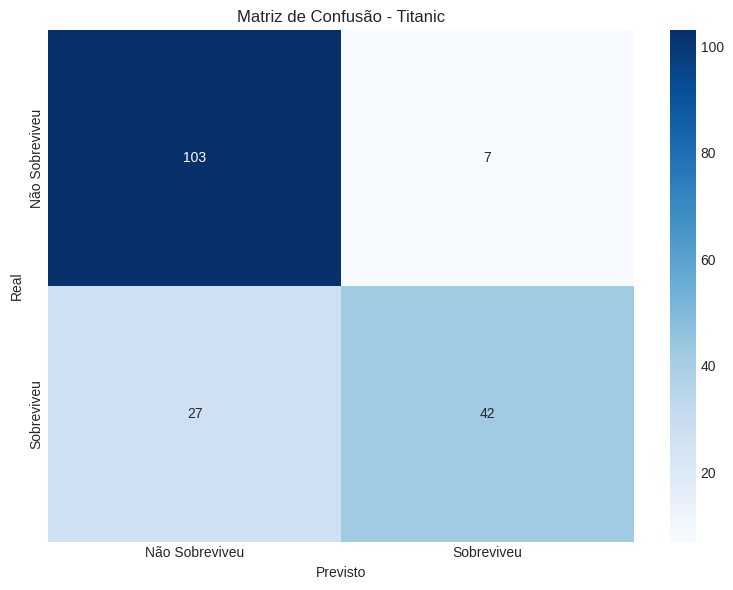

Matriz de confusão:
[[103   7]
 [ 27  42]]


In [10]:
# ============================================================
# CÉLULA 9: MATRIZ DE CONFUSÃO
# ============================================================
matriz = confusion_matrix(y_test, previsoes)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Sobreviveu', 'Sobreviveu'],
            yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão - Titanic')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

print("Matriz de confusão:")
print(matriz)

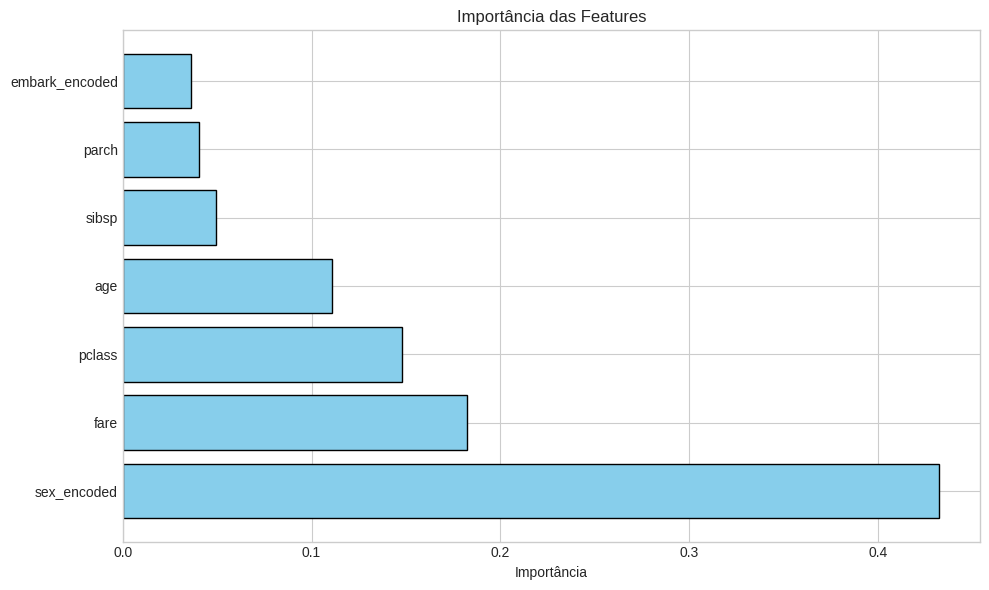

Ranking de importância:
2. sex_encoded: 43.2%
6. fare: 18.2%
1. pclass: 14.8%
3. age: 11.1%
4. sibsp: 5.0%
5. parch: 4.1%
7. embark_encoded: 3.6%


In [11]:
# ============================================================
# CÉLULA 10: IMPORTÂNCIA DAS FEATURES
# ============================================================
importancias = pd.DataFrame({
    'Feature': features,
    'Importancia': modelo_titanic.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importancias['Feature'], importancias['Importancia'],
         color='skyblue', edgecolor='black')
plt.title('Importância das Features')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print("Ranking de importância:")
for i, row in importancias.iterrows():
    print(f"{i+1}. {row['Feature']}: {row['Importancia']*100:.1f}%")

In [12]:
# ============================================================
# CÉLULA 11: PREVER NOVO PASSAGEIRO
# ============================================================
def prever_sobrevivencia(sexo, idade, classe, tarifa, porto):
    sexo_cod = 0 if sexo.lower() == 'female' else 1
    porto_cod = encoder_embark.transform([porto])[0]

    passageiro = pd.DataFrame({
        'pclass': [classe],
        'sex_encoded': [sexo_cod],
        'age': [idade],
        'sibsp': [0],
        'parch': [0],
        'fare': [tarifa],
        'embark_encoded': [porto_cod]
    })

    previsao = modelo_titanic.predict(passageiro)[0]
    prob = modelo_titanic.predict_proba(passageiro)[0][1]

    resultado = "Sobreviveu" if previsao == 1 else "Não Sobreviveu"

    print(f"\n{'='*50}")
    print(f" PREVISÃO")
    print(f"{'='*50}")
    print(f"Passageiro: {sexo}, {idade} anos, {classe}ª classe")
    print(f"Resultado: {resultado}")
    print(f"Probabilidade: {prob*100:.1f}%")

    return resultado, prob

# Testar
prever_sobrevivencia('female', 25, 1, 100, 'Cherbourg')


 PREVISÃO
Passageiro: female, 25 anos, 1ª classe
Resultado: Sobreviveu
Probabilidade: 90.4%


('Sobreviveu', np.float64(0.9035790881868531))

In [13]:
# ============================================================
# CÉLULA 12: SALVAR MODELO
# ============================================================
joblib.dump(modelo_titanic, 'modelo_titanic.pkl')
joblib.dump(encoder_sex, 'encoder_sex.pkl')
joblib.dump(encoder_embark, 'encoder_embark.pkl')

print("✅ Modelo e encoders salvos!")

✅ Modelo e encoders salvos!


In [14]:
# ============================================================
# CÉLULA 13: VALIDAÇÃO CRUZADA
# ============================================================
scores = cross_val_score(modelo_titanic, X, y, cv=5, scoring='accuracy')

print(" VALIDAÇÃO CRUZADA (5 folds)")
print("=" * 60)
print(f"Scores: {scores}")
print(f"Média: {scores.mean()*100:.2f}%")
print(f"Desvio: {scores.std()*100:.2f}%")

 VALIDAÇÃO CRUZADA (5 folds)
Scores: [0.7877095  0.81460674 0.83146067 0.79775281 0.87078652]
Média: 82.05%
Desvio: 2.92%


In [16]:
# ============================================================
# CÉLULA 14: COMPARAR ALGORITMOS
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

algoritmos = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

print(" COMPARAÇÃO DE ALGORITMOS")
print("=" * 60)

for nome, alg in algoritmos.items():
    alg.fit(X_train, y_train)
    preds = alg.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{nome}: {acc*100:.2f}%")

 COMPARAÇÃO DE ALGORITMOS
Random Forest: 82.68%
Logistic Regression: 80.45%
Decision Tree: 83.24%
KNN: 64.80%
